In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

# Add the repo folder for imports
dirpath_repo_root = Path().resolve()
sys.path.append(str(dirpath_repo_root))
print(f'Repo root: {dirpath_repo_root}')

from analysis.ou_tuning import batch_utils
from plot_fi_vi_curves import plot_fi_curve, plot_vi_curve

Repo root: /ddn/niknovikov19/repo/A1_OUinp


In [2]:
dirpath_exp = (dirpath_repo_root / 'sim_output' / 
               'sim_IT5A_kdr_mult_1_ouamp_-0.02_0.1')

dirpath_cfg = dirpath_exp / 'cfg'
fname_cfg_templ = '*_cfg.json'

# Populations to read from the result jsons
pops_used = ['IT5A']

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_cfg,
    cfg_param_fields={
        'stim': 'ou_ramp_offset',   # xarray : json
        'wx': 'bkg_w',
        'rx': 'bkg_r'
    },
    fname_cfg_templ=fname_cfg_templ,
    job_pos_in_fname=0
)
job_idx_xr

<xarray.DataArray 'job_id' (stim: 3, wx: 1, rx: 2)> Size: 48B
array([[[0, 3]],

       [[1, 4]],

       [[2, 5]]])
Coordinates:
  * stim     (stim) float64 24B 0.25 1.0 1.75
  * wx       (wx) float64 8B 0.5
  * rx       (rx) int64 16B 75 150

In [3]:
R = batch_utils.collect_batch_xr_data(
    job_idx_xr,
    dirpath_data=(dirpath_exp / 'rates_xr'),
    fname_data_templ='{job:05d}_*.nc'
)
R

<xarray.DataArray (stim: 3, wx: 1, rx: 2, interval: 2, cell: 359)> Size: 34kB
array([[[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]]],



       [[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]]],



       [[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]]]], shape=(3, 1, 2, 2, 359))
Coordinates:
  * stim        (stim) float64 24B 0.25 1.0 1.75
  * wx          (wx) float64 8B 0.5
  * rx          (rx) int64 16B 75 150
  * cell        (cell) int32 1kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358
    I           (cell) float64 3kB ...
    time_range  (interval) object 16B ...
  * interval    (interval) object 16B 'pre' 'post'

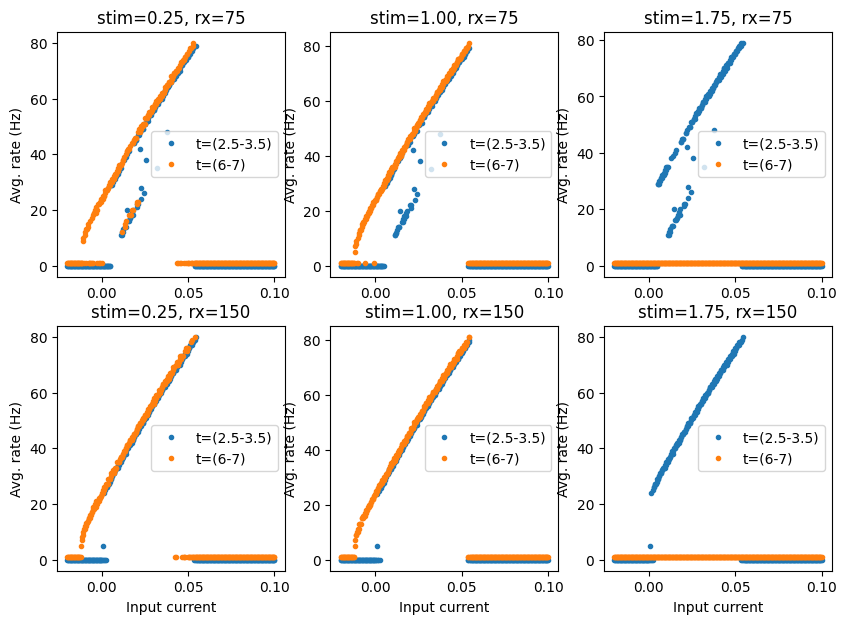

In [4]:
plt.figure(figsize=(10, 7))
nx, ny = 3, 2

for n, amp in enumerate(R.coords['stim']):
    for m, rx in enumerate(R.coords['rx']):
        R_ = R.sel(stim=amp, rx=rx).isel(wx=0)
        plt.subplot(ny, nx, m * nx + n + 1)
        plot_fi_curve(R_, pops_used[0])
        plt.xlabel(None)
        plt.title(f'stim={amp:.2f}, rx={rx:.0f}')
        
for p in [4, 5, 6]:
    plt.subplot(2, 3, p)
    plt.xlabel('Input current')
        

In [5]:
V = batch_utils.collect_batch_xr_data(
    job_idx_xr,
    dirpath_data=(dirpath_exp / 'vstats_xr'),
    fname_data_templ='{job:05d}_*.nc'
)
V

<xarray.Dataset> Size: 142kB
Dimensions:     (stim: 3, wx: 1, rx: 2, cell: 359, interval: 2)
Coordinates:
  * stim        (stim) float64 24B 0.25 1.0 1.75
  * wx          (wx) float64 8B 0.5
  * rx          (rx) int64 16B 75 150
  * cell        (cell) int32 1kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358
    I           (cell) float64 3kB ...
    time_range  (interval) object 16B ...
  * interval    (interval) object 16B 'pre' 'post'
Data variables:
    vmin        (stim, wx, rx, cell, interval) float64 34kB -110.5 ... -19.68
    vmax        (stim, wx, rx, cell, interval) float64 34kB -103.5 ... -14.53
    vmed        (stim, wx, rx, cell, interval) float64 34kB -107.9 ... -18.19
    vavg        (stim, wx, rx, cell, interval) float64 34kB -107.7 ... -18.24

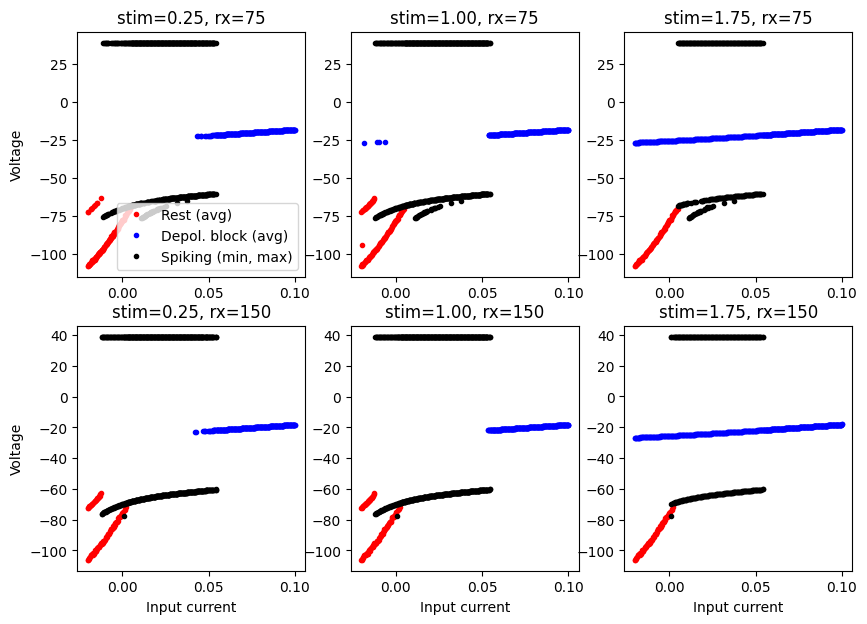

In [6]:
plt.figure(figsize=(10, 7))
nx, ny = 3, 2

for n, amp in enumerate(R.coords['stim']):
    for m, rx in enumerate(R.coords['rx']):
        V_ = V.sel(stim=amp, rx=rx).isel(wx=0)
        plt.subplot(ny, nx, m * nx + n + 1)
        plot_vi_curve(V_, pops_used[0])
        plt.xlabel(None)
        plt.ylabel(None)
        plt.title(f'stim={amp:.2f}, rx={rx:.0f}')

for p in [4, 5, 6]:
    plt.subplot(2, 3, p)
    plt.xlabel('Input current')
for p in [1, 4]:
    plt.subplot(2, 3, p)
    plt.ylabel('Voltage')
for p in range(2, 7):
    plt.subplot(2, 3, p)
    plt.gca().get_legend().remove()